In [1]:
import icechunk
import numpy as np
import s3fs
import xarray as xr

from srm.downscaling_utils import rechunk

In [2]:
BUCKET = "carbonplan-srm"
REGION = "us-west-2"
root_path = "s3://carbonplan-srm/output/production/"
version = "v2026.06.22"


def get_fname(root_path, var, scenario, version, ens, scenario2=None):
    if scenario2 is None:
        scenario2 = scenario
    return (
        root_path
        + version
        + "/"
        + scenario
        + "/CESM2-WACCM/"
        + var
        + "/"
        + ens
        + "/global/era5/*/"
        + scenario2
        + ".icechunk/"
    )


def resolve_s3_glob(fname: str) -> str:
    """Resolve a single-wildcard s3:// glob (the era5/*/ hash dir) to one concrete path."""
    fs = s3fs.S3FileSystem(anon=True)
    matches = fs.glob(fname.rstrip("/"))
    if not matches:
        raise FileNotFoundError(f"No S3 paths matched: {fname}")
    if len(matches) > 1:
        raise ValueError(f"Glob matched {len(matches)} paths, expected 1: {matches}")
    return "s3://" + matches[0]


def open_icechunk(path):
    prefix = path.replace(f"s3://{BUCKET}/", "").strip("/")
    storage = icechunk.s3_storage(bucket=BUCKET, prefix=prefix, anonymous=True, region=REGION)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    return xr.open_dataset(session.store, engine="zarr", chunks={})


def load_downscaling_store(scenario, ens, variables=("tas", "pr", "rsds", "hurs")):
    """Open every variable for a scenario and merge into one Dataset."""
    das = []
    for var in variables:
        fname = resolve_s3_glob(get_fname(root_path, var, scenario, version, ens))
        da = open_icechunk(fname)[var].drop_vars("dayofyear", errors="ignore")
        das.append(da)
    return xr.merge(das, join="outer")

In [3]:
historical_ds = load_downscaling_store("historical", ens="r3i1p1f1")
g6_ds = load_downscaling_store("g6-1.5k", ens="003")
ssp245_ds = load_downscaling_store("ssp245", ens="003")

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(


US subset: {'time': 31411, 'lon': 281, 'lat': 101}


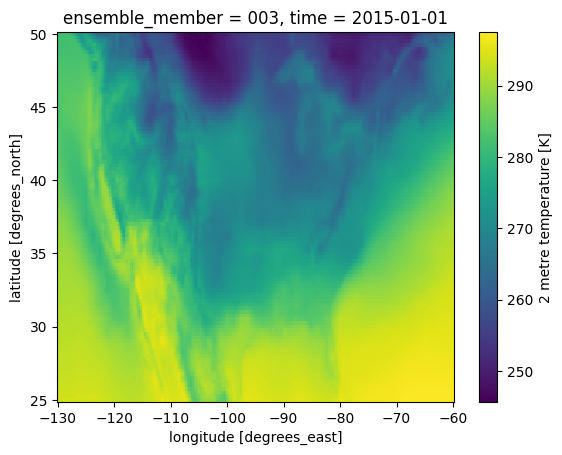

In [4]:
# Check data
def subset_bbox(ds, lon_min, lon_max, lat_min, lat_max):
    # Handle both ascending and descending latitude coordinates
    lat_slice = slice(lat_min, lat_max) if ds.lat[0] < ds.lat[-1] else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if ds.lon[0] < ds.lon[-1] else slice(lon_max, lon_min)
    return ds.sel(lat=lat_slice, lon=lon_slice)


# Example usage
ds_western_us = subset_bbox(ssp245_ds, lon_min=-130, lon_max=-60, lat_min=25, lat_max=50)
print(f"US subset: {dict(ds_western_us.sizes)}")
ds_western_us.tas.squeeze().isel(time=0).plot()

In [5]:
import matplotlib.pyplot as plt

from srm import catalog

In [10]:
testing_period = slice("2035-01-01", "2084-12-31")

g6_ds = g6_ds.sel(time=testing_period)
ssp245_ds = ssp245_ds.sel(time=testing_period)

In [15]:
def rechunk_ds(ds, pattern):
    return xr.merge([rechunk(ds[v].load(), pattern=pattern) for v in variables])

In [17]:
training_period = slice("1984-01-01", "2014-12-31")
testing_period = slice("2035-01-01", "2084-12-31")
variables = ["tas", "pr", "hurs", "rsds"]

In [18]:
gcm = "CESM2-WACCM"
scenario = "ssp245"  # "historical", "SSP245", "G6-1.5K"
dataset_name = f"{gcm}"  # -{scenario}-icechunk"

raw_fut_full = catalog.get(dataset_name).to_xarray()[scenario].ds[variables].isel(ensemble_member=2)
raw_ssp_fut = raw_fut_full.sel(time=testing_period)

In [19]:
gcm = "CESM2-WACCM"
scenario = "g6_1p5k"  # "historical", "SSP245", "G6-1.5K"
dataset_name = f"{gcm}"  # -{scenario}-icechunk"

raw_fut_full = catalog.get(dataset_name).to_xarray()[scenario].ds[variables].isel(ensemble_member=2)
raw_g6_fut = raw_fut_full.sel(time=testing_period)

In [22]:
raw_g6_fut = rechunk_ds(raw_g6_fut, pattern="full_time")
raw_ssp_fut = rechunk_ds(raw_ssp_fut, pattern="full_time")

Extracting NYC ...
Extracting Lima ...
Extracting Kampala ...
Extracting Singapore ...
Extracting Paris ...
Extracting Cape Town ...
Extracting Bogotá ...
Extracting Bangkok ...
Extracting Mexico City ...


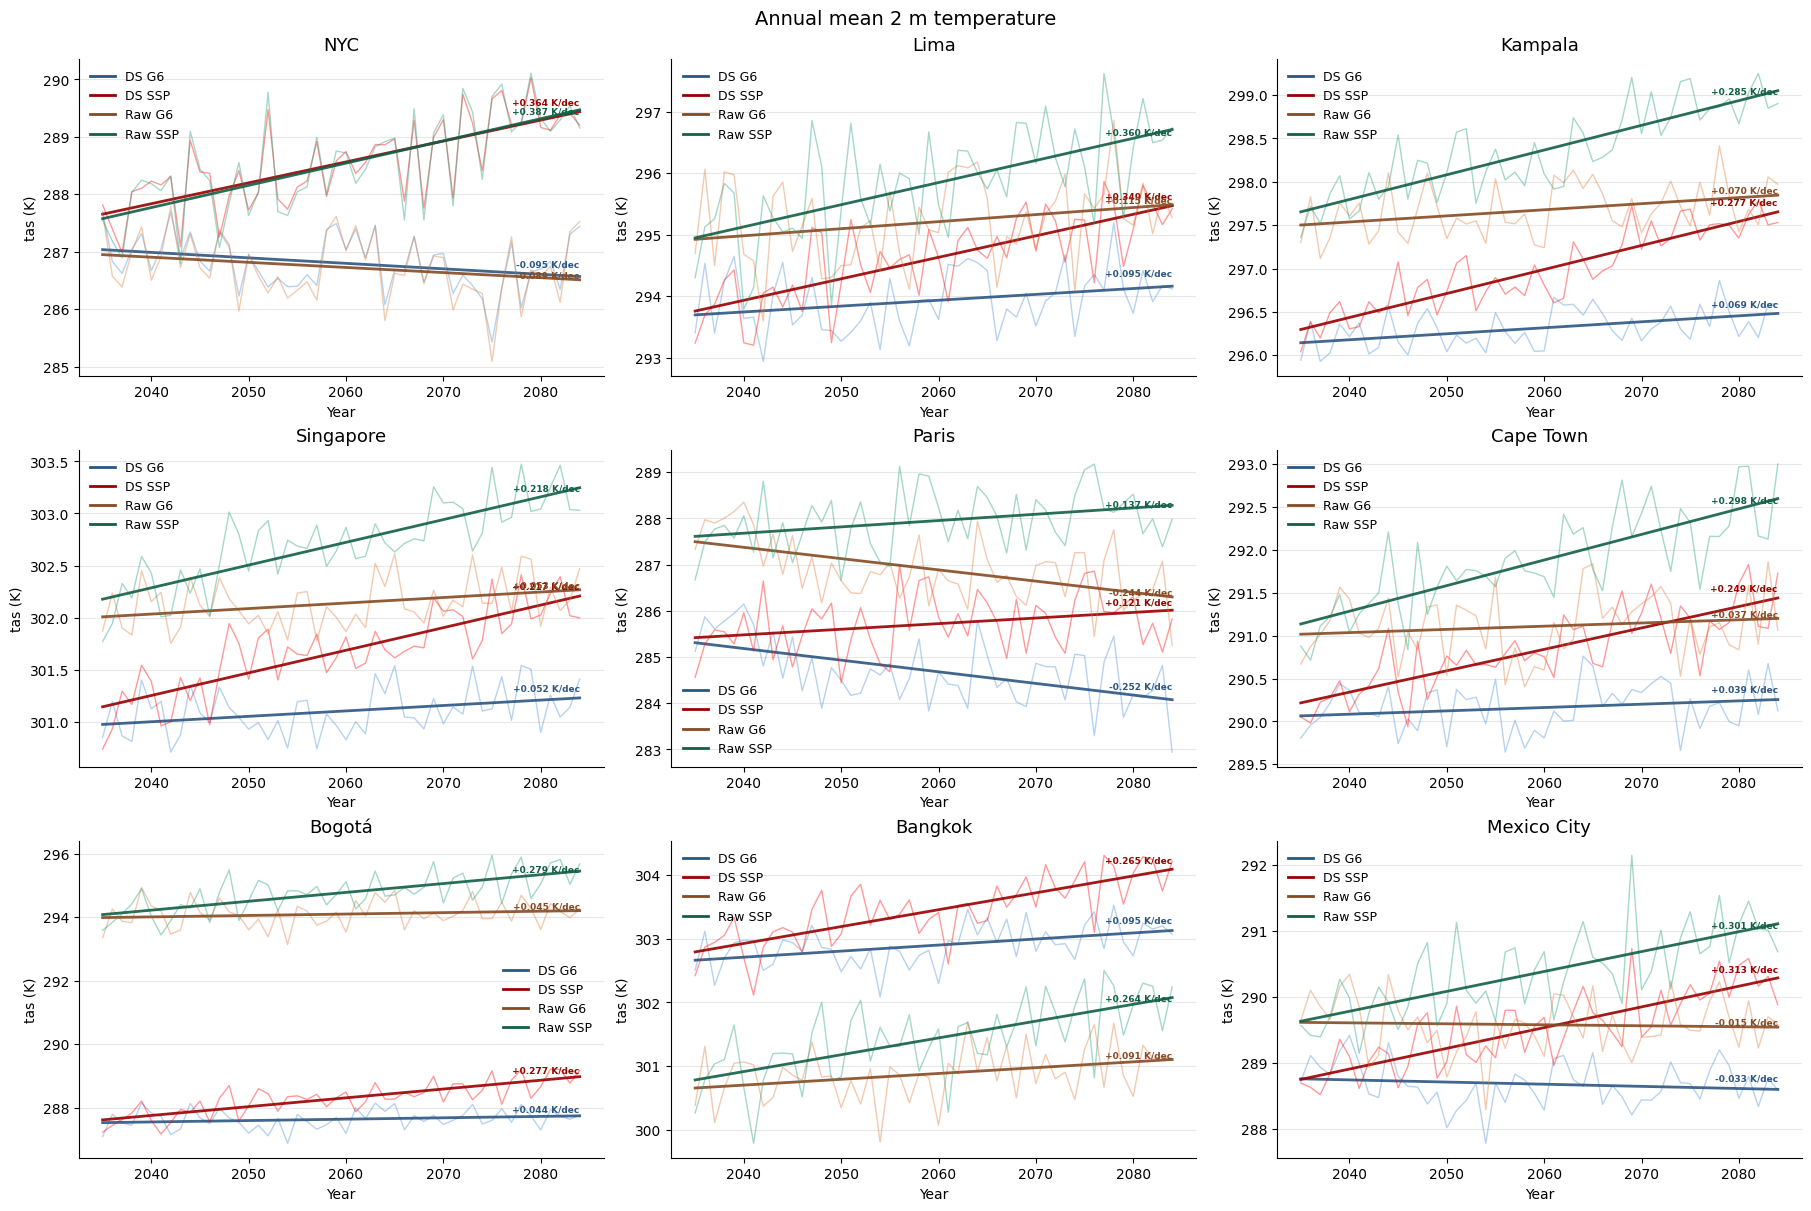

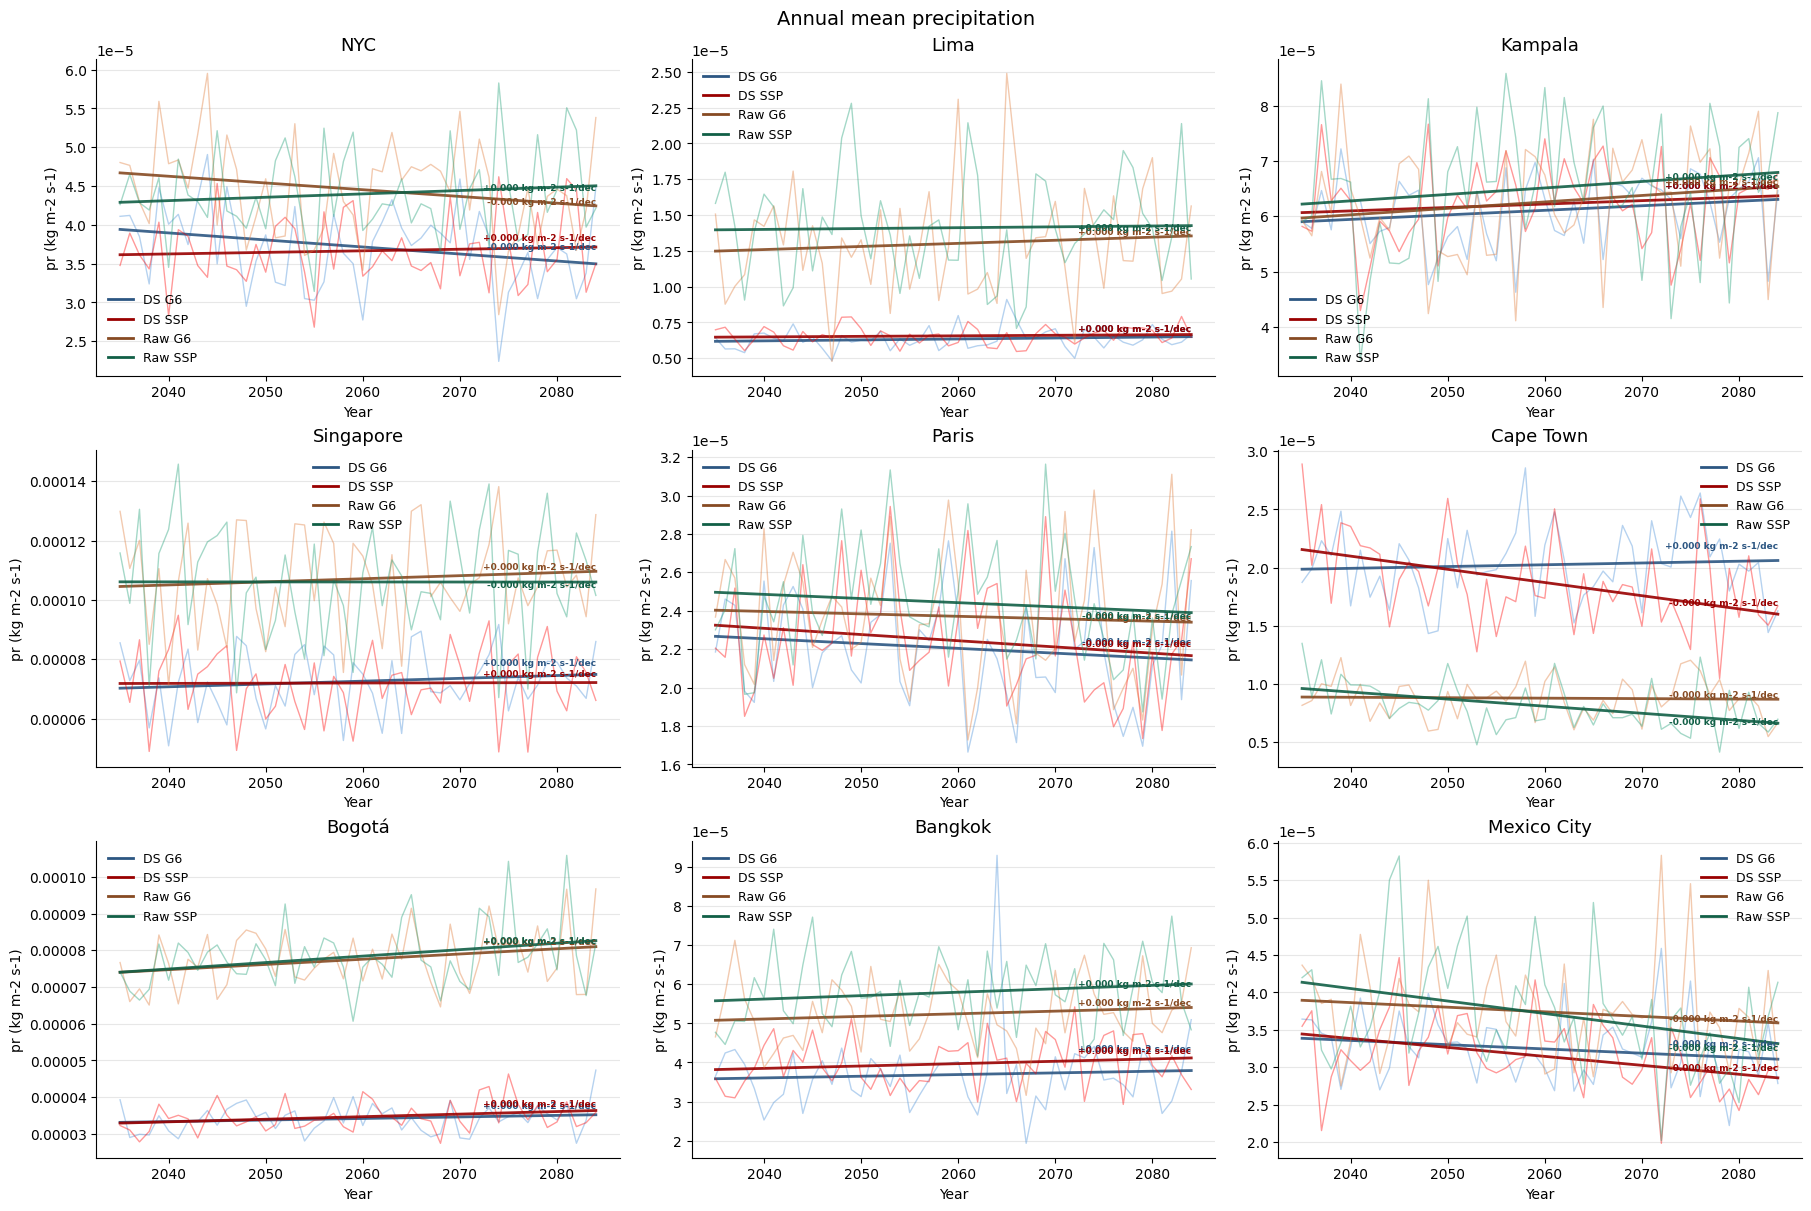

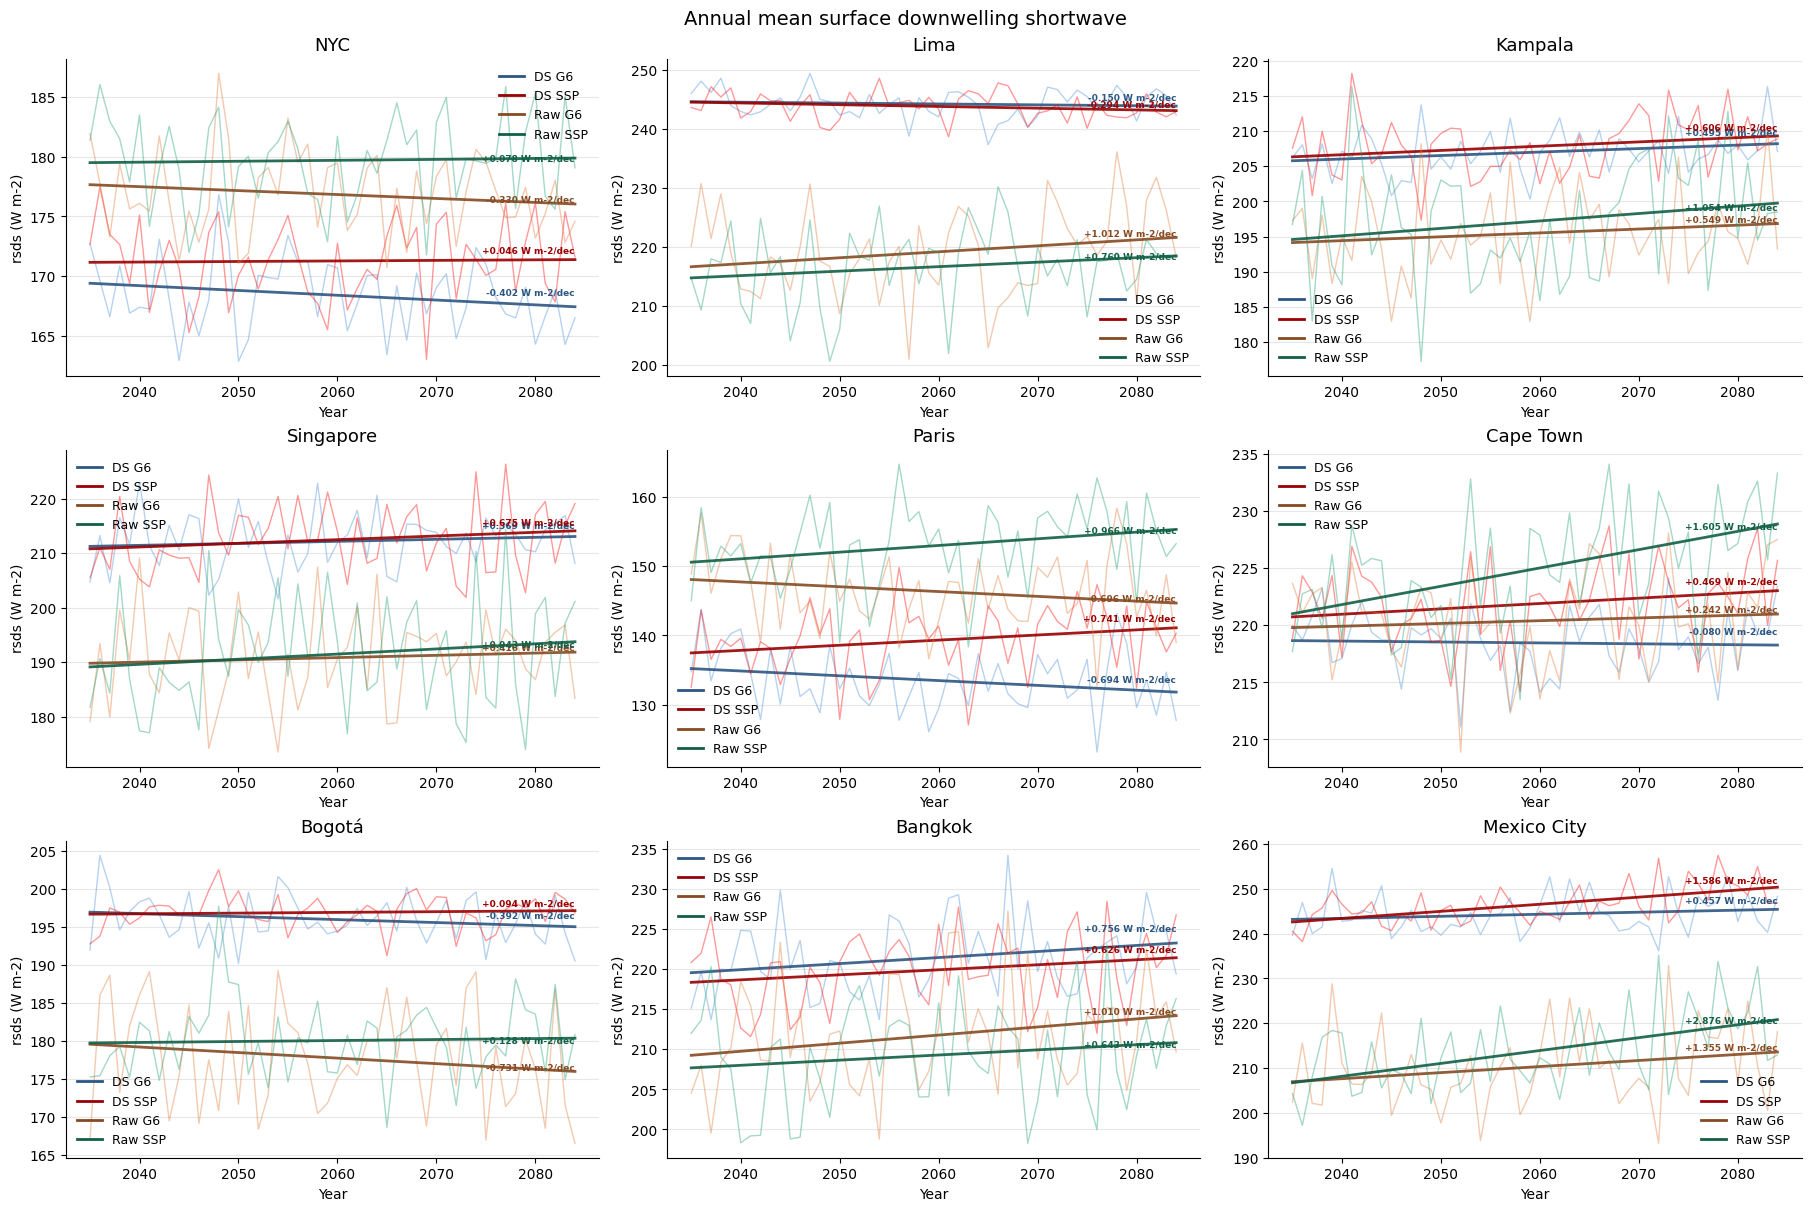

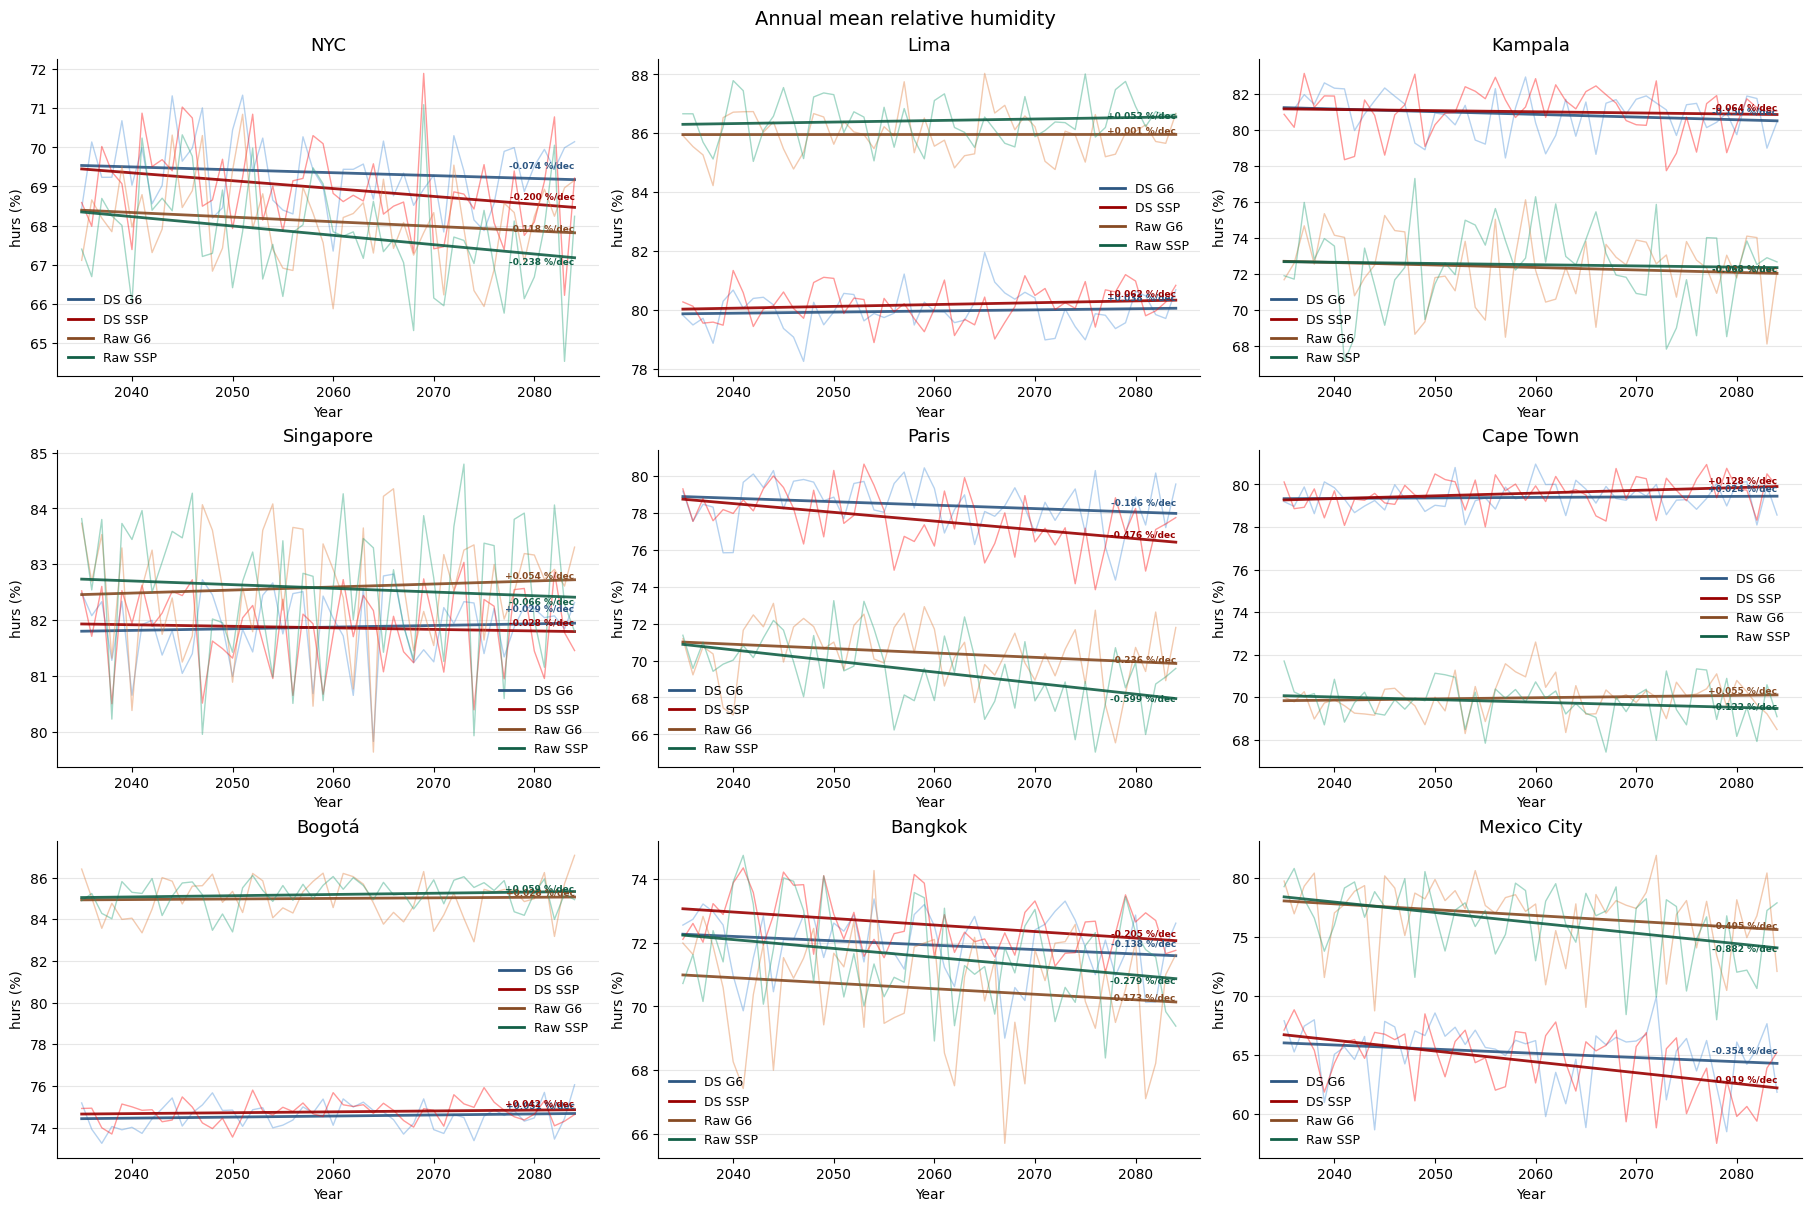

In [23]:
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

SOURCES = {
    "DS G6": g6_ds,
    "DS SSP": ssp245_ds,
    "Raw G6": raw_g6_fut,
    "Raw SSP": raw_ssp_fut,
}
COLORS = {
    "DS G6": "#4A90D9",
    "DS SSP": "red",
    "Raw G6": "#E07B39",
    "Raw SSP": "#1D9E75",
}
SLOPE_VOFFSET = {"DS G6": 2, "DS SSP": 1, "Raw G6": 0, "Raw SSP": -1}

VARIABLES = ["tas", "pr", "rsds", "hurs"]
UNIT_FALLBACK = {"tas": "K", "pr": "mm/day", "rsds": "W/m²", "hurs": "%"}
VAR_TITLE = {
    "tas": "Annual mean 2 m temperature",
    "pr": "Annual mean precipitation",
    "rsds": "Annual mean surface downwelling shortwave",
    "hurs": "Annual mean relative humidity",
}
CITIES = {
    "NYC": (40.7128, -74.0060),
    "Lima": (-12.0464, -77.0428),
    "Kampala": (0.3476, 32.5825),
    "Singapore": (1.3521, 103.8198),
    "Paris": (48.8566, 2.3522),
    "Cape Town": (-33.9249, 18.4241),
    "Bogotá": (4.7110, -74.0721),
    "Bangkok": (13.7563, 100.5018),
    "Mexico City": (19.4326, -99.1332),
}


def darken(hex_color, factor=0.6):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r * factor, g * factor, b * factor)


city_data = {city: {} for city in CITIES}
for city, (lat, lon) in CITIES.items():
    print(f"Extracting {city} ...")
    for src, ds in SOURCES.items():
        pt = ds.sel(lat=lat, lon=lon, method="nearest").drop_vars(
            ["lat", "lon", "ensemble_member"], errors="ignore"
        )
        city_data[city][src] = pt[VARIABLES].load()

for var in VARIABLES:
    fig, axes = plt.subplots(3, 3, figsize=(18, 12), constrained_layout=True)
    axes_flat = axes.flatten()

    for i, (city, sources) in enumerate(city_data.items()):
        ax = axes_flat[i]
        handles, units = [], UNIT_FALLBACK[var]
        for src, ds in sources.items():
            da = ds[var]
            units = da.attrs.get("units", UNIT_FALLBACK[var])
            annual = da.resample(time="YE").mean()
            years = annual.time.dt.year.values
            vals = annual.values.astype(np.float32)

            color, dk_color = COLORS[src], darken(COLORS[src], 0.6)
            ax.plot(years, vals, color=color, lw=1, alpha=0.4)

            mask = np.isfinite(vals)
            if mask.sum() < 2:
                continue
            m, b = np.polyfit(years[mask], vals[mask], 1)
            fit_years = np.array([years[mask][0], years[mask][-1]])
            fit_vals = m * fit_years + b
            ax.plot(fit_years, fit_vals, color=dk_color, lw=2, alpha=0.9)

            yrange = np.nanmax(vals) - np.nanmin(vals)
            offset = SLOPE_VOFFSET[src] * 0.03 * (yrange or 1)
            ax.text(
                fit_years[-1],
                fit_vals[-1] + offset,
                f"{m * 10:+.3f} {units}/dec",
                color=dk_color,
                fontsize=6.5,
                ha="right",
                va="bottom",
                fontweight="bold",
            )
            handles.append(mlines.Line2D([], [], color=dk_color, lw=2, label=src))

        ax.set_title(city, fontsize=13, fontweight="500")
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylabel(f"{var} ({units})", fontsize=10)
        ax.legend(handles=handles, fontsize=9, frameon=False)
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(VAR_TITLE[var], fontsize=14, fontweight="500")
    # plt.savefig(f"trend_9cities_{var}.png", dpi=150, bbox_inches="tight")
    plt.show()

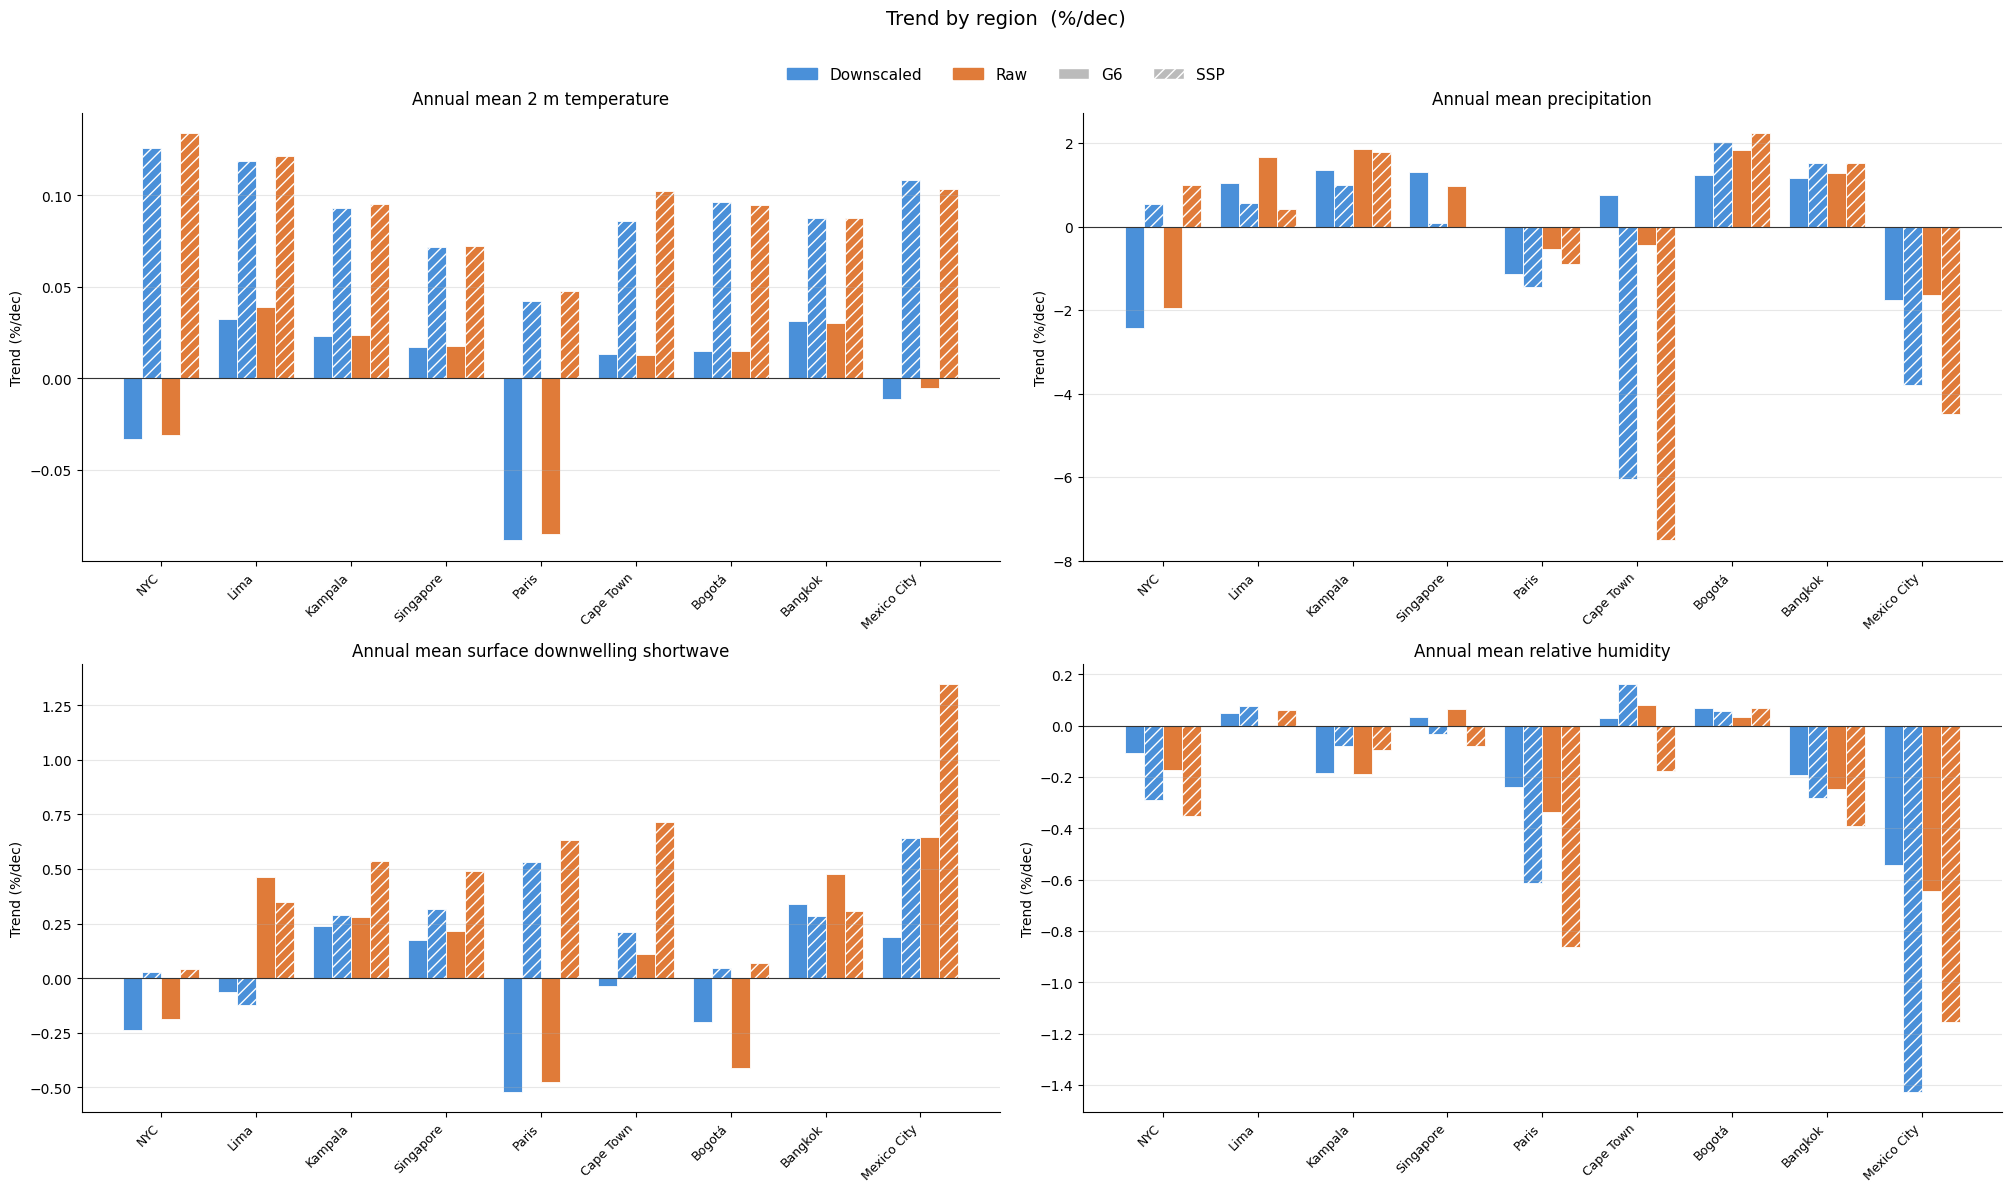

In [24]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

SRC_ORDER = ["DS G6", "DS SSP", "Raw G6", "Raw SSP"]
METHOD_COLOR = {"DS": "#4A90D9", "Raw": "#E07B39"}
SCEN_HATCH = {"G6": "", "SSP": "///"}


def method_of(s):
    return "DS" if s.startswith("DS") else "Raw"


def scen_of(s):
    return "G6" if "G6" in s else "SSP"


USE_PERCENT = True

trends = {var: {c: {} for c in CITIES} for var in VARIABLES}
for var in VARIABLES:
    for city in CITIES:
        for src in SRC_ORDER:
            annual = city_data[city][src][var].resample(time="YE").mean()
            years = annual.time.dt.year.values.astype(float)
            vals = annual.values.astype(np.float32)
            mask = np.isfinite(vals)
            if mask.sum() < 2:
                trends[var][city][src] = np.nan
                continue
            m, _ = np.polyfit(years[mask], vals[mask], 1)
            slope_dec = m * 10
            if USE_PERCENT:
                denom = np.nanmean(vals[mask])
                slope_dec = slope_dec / denom * 100 if denom else np.nan
            trends[var][city][src] = slope_dec

cities = list(CITIES.keys())
n_src = len(SRC_ORDER)
group_w = 0.8
bar_w = group_w / n_src

fig, axes = plt.subplots(2, 2, figsize=(20, 11), constrained_layout=True)
for ax, var in zip(axes.flat, VARIABLES):
    for j, src in enumerate(SRC_ORDER):
        xs = np.arange(len(cities)) + (j - (n_src - 1) / 2) * bar_w
        ys = [trends[var][c][src] for c in cities]
        ax.bar(
            xs,
            ys,
            width=bar_w,
            color=METHOD_COLOR[method_of(src)],
            hatch=SCEN_HATCH[scen_of(src)],
            edgecolor="white",
            linewidth=0.6,
        )

    if USE_PERCENT:
        unit = "%/dec"
    else:
        unit = city_data[cities[0]][SRC_ORDER[0]][var].attrs.get("units", "") + "/dec"

    ax.axhline(0, color="#333", lw=0.8)
    ax.set_xticks(np.arange(len(cities)))
    ax.set_xticklabels(cities, rotation=45, ha="right", fontsize=9)
    ax.set_title(VAR_TITLE[var], fontsize=12, fontweight="500")
    ax.set_ylabel(f"Trend ({unit})", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    mpatches.Patch(color=METHOD_COLOR["DS"], label="Downscaled"),
    mpatches.Patch(color=METHOD_COLOR["Raw"], label="Raw"),
    mpatches.Patch(facecolor="#bbb", edgecolor="white", hatch="", label="G6"),
    mpatches.Patch(facecolor="#bbb", edgecolor="white", hatch="///", label="SSP"),
]
fig.legend(
    handles=legend_handles,
    ncol=4,
    loc="upper center",
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.03),
)
fig.suptitle(
    "Trend by region  (" + ("%/dec" if USE_PERCENT else "units/dec") + ")",
    fontsize=14,
    fontweight="500",
    y=1.07,
)
# plt.show()
plt.savefig("trend_cities_allvars_bar.png", dpi=300, bbox_inches="tight")

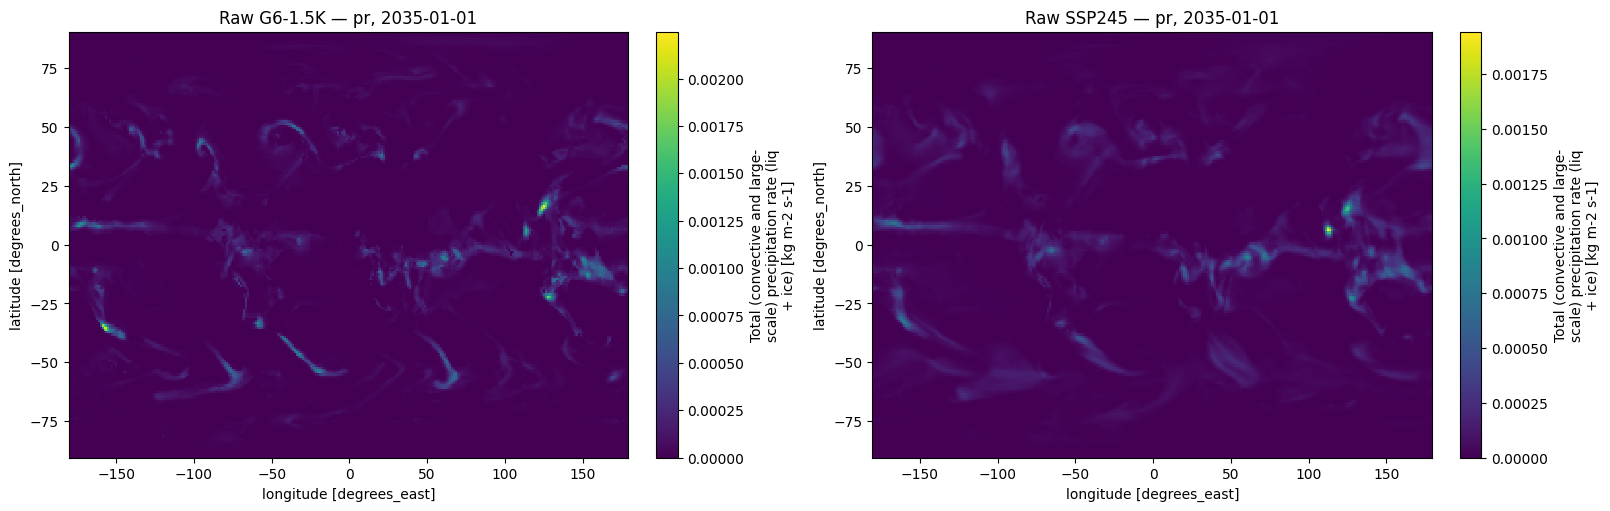

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

raw_g6_fut["pr"].isel(time=0).plot(ax=axes[0])
axes[0].set_title("Raw G6-1.5K — pr, 2035-01-01")

raw_ssp_fut["pr"].isel(time=0).plot(ax=axes[1])
axes[1].set_title("Raw SSP245 — pr, 2035-01-01")

plt.show()

In [26]:
DATASETS = {
    "g6_ds": g6_ds,
    "ssp245_ds": ssp245_ds,
    "raw_g6_fut": raw_g6_fut,
    "raw_ssp_fut": raw_ssp_fut,
}

for name, ds in DATASETS.items():
    pr = ds["pr"].isel(time=0)
    print(
        f"{name:12s}: min={float(pr.min()):.3e}  max={float(pr.max()):.3e}  "
        f"mean={float(pr.mean()):.3e}  units={pr.attrs.get('units')}  "
        f"dtype={ds['pr'].dtype}"
    )

g6_ds       : min=-1.073e-03  max=2.084e-03  mean=2.448e-05  units=kg m-2 s-1  dtype=float32
ssp245_ds   : min=-1.778e-04  max=1.489e-03  mean=2.709e-05  units=kg m-2 s-1  dtype=float32
raw_g6_fut  : min=0.000e+00  max=2.247e-03  mean=2.520e-05  units=kg m-2 s-1  dtype=float32
raw_ssp_fut : min=0.000e+00  max=1.944e-03  mean=2.733e-05  units=kg m-2 s-1  dtype=float32


In [27]:
DATASETS = {
    "g6_ds": g6_ds,
    "ssp245_ds": ssp245_ds,
    "raw_g6_fut": raw_g6_fut,
    "raw_ssp_fut": raw_ssp_fut,
}

for name, ds in DATASETS.items():
    da = ds["pr"]
    n_nan = int(da.isnull().sum().compute())  # reads the full pr array from S3
    total = int(da.size)
    print(f"{name:12s} pr  {n_nan:>13,} / {total:>13,}  ({100 * n_nan / total:.4f}%)")

g6_ds        pr     52,670,492 / 18,961,377,120  (0.2778%)
ssp245_ds    pr     52,670,492 / 18,961,377,120  (0.2778%)
raw_g6_fut   pr              0 / 1,009,870,848  (0.0000%)
raw_ssp_fut  pr              0 / 1,009,870,848  (0.0000%)
